*  DSC 530
*  Weeks 1 & 2
*  Doug Nolan

# Week 9 & 10

### Exercise 1(a, c-e), 2(a-e), and 3(a-e) in Chapter 9 from Hands-On Data Analysis with Pandas (Molin, 2021)

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    fowlkes_mallows_score,
    r2_score,
    mean_squared_error,
    accuracy_score,
    classification_report)

from ml_utils.classification import plot_roc
from ml_utils.regression import plot_residuals
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

# find git link to install these packages
# https://github.com/stefmolin/ml-utils/tree/master/ml_utils
# from ml_utils.regression import plot_residuals
# from ml_utils.classification import plot_roc, confusion_matrix_visual

In [2]:
# why the fundip is red split by comma but white is a semi colon 
red = pd.read_csv("Bellevue/dsc530/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_09/data/winequality-red.csv", sep=",")
white = pd.read_csv("Bellevue/dsc530/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_09/data/winequality-white.csv", sep=";")


In [3]:
print(white.columns)

white.head()

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
print(red.columns)

red.head()

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# combine files
red["wine_type"] = "red"
white["wine_type"] = "white"

wine = pd.concat([red, white], join='outer', ignore_index=True)

print("Combined wine dataset shape:")
print(wine.shape)

wine.head()

Combined wine dataset shape:
(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [6]:
# build pipeline - don't use quality column
# turn wine type into boolean
wine["wine_label"] = wine["wine_type"].map({
    "red": 0,
    "white":1 })

# features exlcuding quality and labels
x_wine = wine.drop(columns=[
    "quality",
    "wine_type",
    "wine_label"])

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    ))
])

pipeline.fit(x_wine)

clusters = pipeline.named_steps["kmeans"].labels_

In [7]:
# evaluate with Fowlkes-mallows index

fmi = fowlkes_mallows_score(
    wine["wine_label"],
    clusters)
print("\nFowlkes-Mallows Index:")
print(fmi)


Fowlkes-Mallows Index:
0.9779330493137359


In [8]:
# find cluster centers

centers_scaled = pipeline.named_steps["kmeans"].cluster_centers_

# convert centers back to original scale
scaler = pipeline.named_steps["scaler"]

centers_original = scaler.inverse_transform(centers_scaled)

cluster_centers = pd.DataFrame(
    centers_original,
    columns=x_wine.columns)

print("\nCluster Centers:")
print(cluster_centers)


Cluster Centers:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       6.851710          0.274608     0.335244        6.393800   0.045130   
1       8.290378          0.532028     0.269519        2.632643   0.088275   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            35.520803            138.463337  0.994005  3.187627   0.488803   
1            15.754872             48.570646  0.996741  3.309787   0.656827   

     alcohol  
0  10.522128  
1  10.402132  


# Exercise 2


Stars Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temperature   2793 non-null   float64
 1   magV          1274 non-null   float64
 2   mass          3090 non-null   float64
 3   spectraltype  1206 non-null   object 
 4   magJ          1563 non-null   float64
 5   radius        2721 non-null   float64
 6   magB          1003 non-null   float64
 7   magH          1556 non-null   float64
 8   magK          1585 non-null   float64
 9   metallicity   2411 non-null   float64
 10  name          3183 non-null   object 
 11  planets       3183 non-null   float64
dtypes: float64(10), object(2)
memory usage: 298.5+ KB
None

Summary Statistics:
        temperature         magV         mass         magJ       radius  \
count   2793.000000  1274.000000  3090.000000  1563.000000  2721.000000   
mean    5532.146084    10.304334     0.

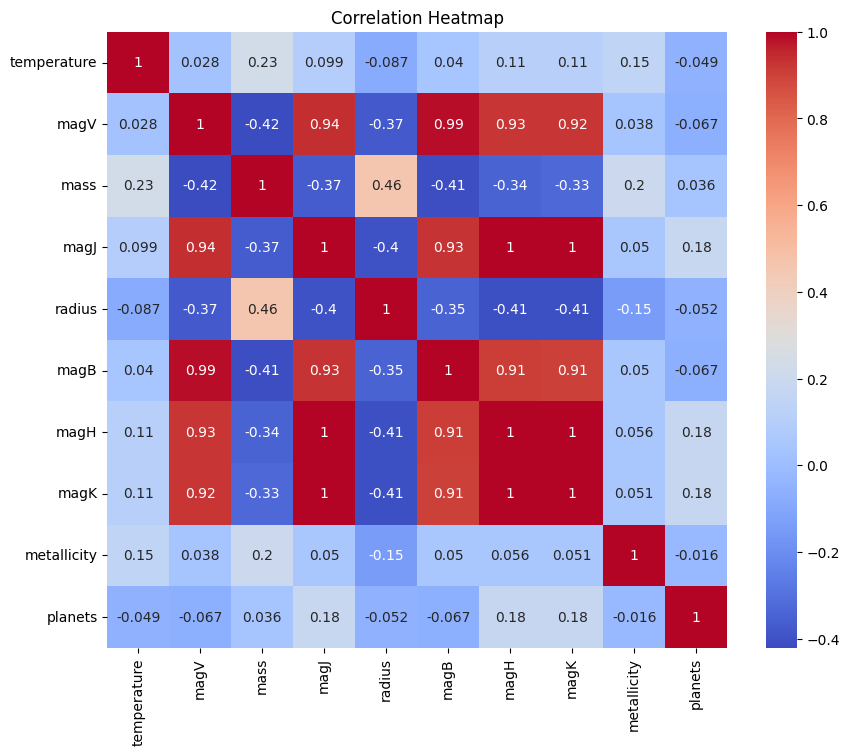

In [9]:
# predict start temperature
# initial EDA
stars = pd.read_csv("Bellevue/dsc530/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_09/data/stars.csv")
print("\nStars Dataset Info:")
print(stars.info())

print("\nSummary Statistics:")
print(stars.describe())

print("\nMissing Values:")
print(stars.isnull().sum())

# Numeric columns only
numeric_cols = stars.select_dtypes(include=np.number).columns

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    stars[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# prepare features and target
# predict temp

data = stars[['metallicity', 'temperature', 'magJ', 'radius', 'magB', 'magV', 'magK', 'mass', 'planets']].dropna()
y = data.pop('temperature')
x = data

# numeric regressors only

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=69
)


In [30]:
# build linear regression model
lr = LinearRegression().fit(X_train, y_train)
r2_val = lr.score(X_test, y_test) 
print("R2 value:" , r2_val)


rmse = np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))

print("Root Mean Square Error (RMSE):" , rmse)

R2 value: 0.7832721955902456
Root Mean Square Error (RMSE): 432.4637353446679


In [33]:
# find he linear regression equation
coef = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": lr.coef_
})

print("\nIntercept:")
print(lr.intercept_)

print("\nRegression Coefficients:")
print(coef)


Intercept:
6557.580774628144

Regression Coefficients:
       Feature  Coefficient
0  metallicity   -27.245129
1         magJ -1021.580866
2       radius     1.135245
3         magB  -314.563163
4         magV  -145.476029
5         magK  1522.414584
6         mass   219.613265
7      planets   -12.531272


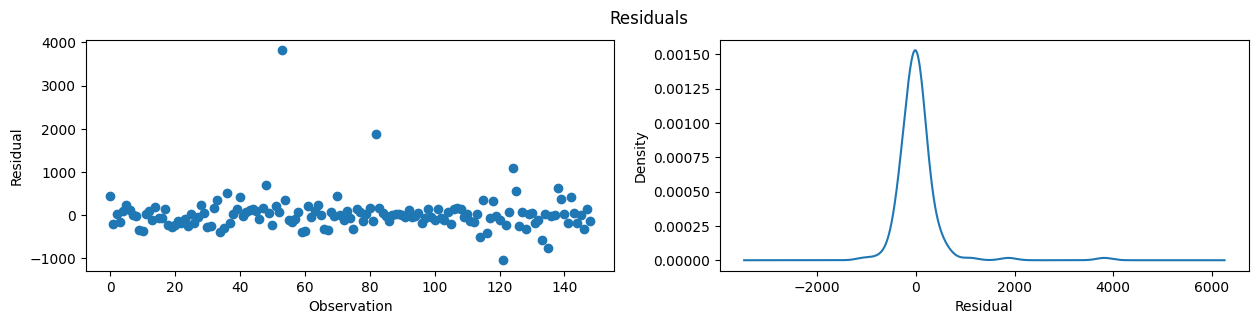

In [51]:
# visualize the residuals using plot from  ml_itl

plot_residuals(
    y_test, lr.predict(X_test))

plt.show()

In [66]:
# !pip install git+https://github.com/stefmolin/ml-utils.git
# this was a great learning activity to findout how to install the package :) 

# Exercise 3

In [59]:
#planets file, build logistic regression. make new column for shorter than earth years 
planets = pd.read_csv("Bellevue/dsc530/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_09/data/planets.csv")


planets["shorter_than_earth"] = (
    planets["period"] < 365).astype(int)

planets.head()

data = planets[['shorter_than_earth', 'semimajoraxis', 'mass', 'eccentricity']].dropna()
y = data.pop('shorter_than_earth')
x = data

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size =0.25, random_state=10, stratify=y)




In [58]:
# find accuracy score
lm = LogisticRegression(random_state=10).fit(X_train, y_train)
lm.score(X_test, y_test)


0.9773462783171522

In [61]:
# use classification_report() , precision, recall and F1 for each class
preds = lm.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97       103
           1       0.98      0.99      0.98       206

    accuracy                           0.98       309
   macro avg       0.98      0.97      0.97       309
weighted avg       0.98      0.98      0.98       309



<Axes: title={'center': 'ROC curve'}, xlabel='False Positive Rate (FPR)', ylabel='True Positive Rate (TPR)'>

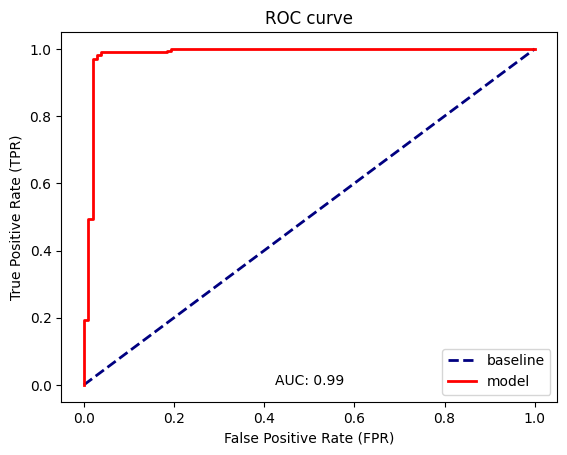

In [63]:
# plot_roc() plot ROC
plot_roc(y_test, lm.predict_proba(X_test)[:,1])

<Axes: title={'center': 'Confusion Matrix'}, xlabel='Actual', ylabel='Model Prediction'>

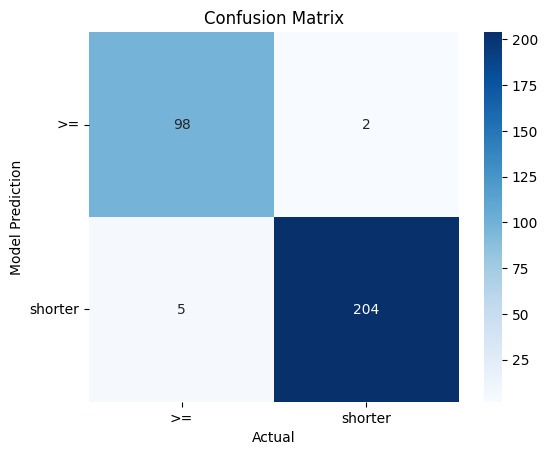

In [65]:
# confusion matrix
from ml_utils.classification import confusion_matrix_visual

confusion_matrix_visual(y_test, preds, ['>=', 'shorter'])